# Euro-SAM 2026 — Ouseburn synthetic sewer network
Steps 1–4: generate the network (SWMManywhere), redesign and check the hydraulics, place sensors, simulate normal and disturbed scenarios → `ouseburn_dataset/`.

Run top to bottom. Outputs shown are from the run reported in the EURO-SAM slides.

In [1]:
# Mount Google Drive and move into the project folder.
# Each collaborator sets PROJECT to where the shared "Euro-SAM 2026" folder
# (or a clone of the GitHub repository) lives on THEIR Drive.
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = "/content/drive/MyDrive/Colab Notebooks/Euro-SAM 2026"
os.chdir(PROJECT)
print("Working in:", os.getcwd())
print(sorted(os.listdir(".")))


Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Euro-SAM 2026
 cache		      ouseburn_config.yml    ouseburn_output
'Euro-SAM v0.ipynb'   ouseburn_dataset	     ouseburn_scenarios.py
 Euro_SAM_v1.ipynb    ouseburn_diagnose.py


In [2]:
!pip install -q swmmanywhere

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 63.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 1. Generate the network (SWMManywhere)
Reuses the existing model for the configured bbox; set `REGENERATE = True` to rebuild.


BBox [-1.6, 54.9645, -1.582, 54.98]  ≈ 1150 m × 1714 m
Reusing existing model (set REGENERATE = True to rebuild): ouseburn_output/ouseburn/bbox_2/model_2/model_2.inp

Network checks
Nodes: 610   Edges: 607   CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / UTM zone 30N", "base_crs": {"type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", 

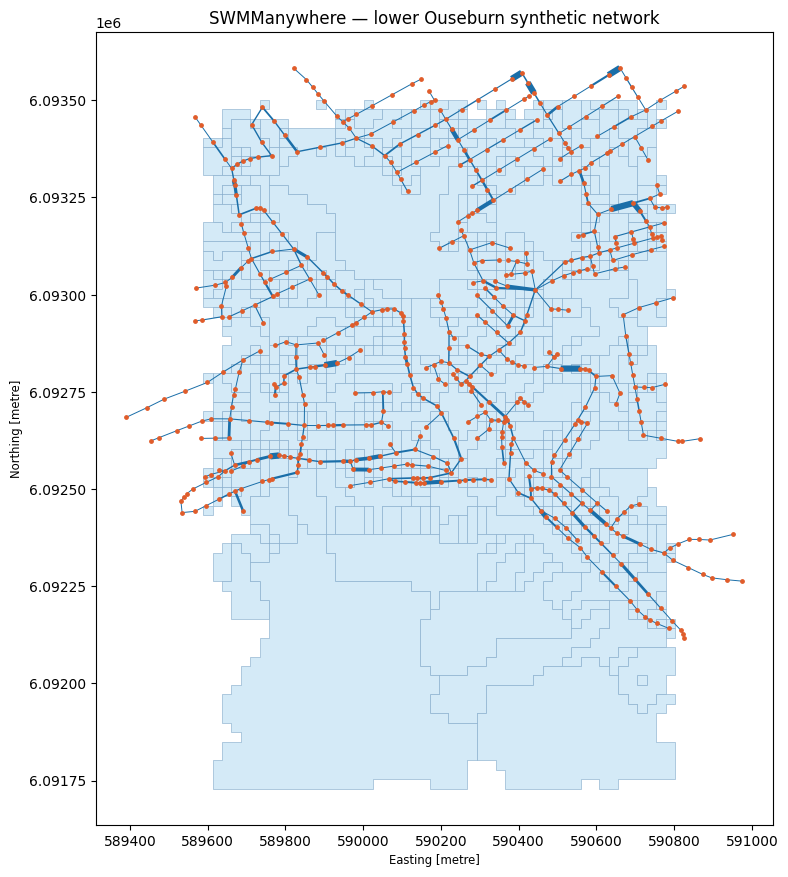

In [3]:
"""
Ouseburn sewer network generation with SWMManywhere (verified against v0.2.4)
==============================================================================
Reads settings from ouseburn_config.yml (single source of truth), runs the
synthesis + a short SWMM simulation, then checks the result is usable for the
graph-learning demo (connectivity, outfalls, slopes, diameters).

Outputs (in ./ouseburn_output/ouseburn/bbox_N/model_M/):
    model_M.inp              SWMM model
    nodes.geoparquet         junctions + outfalls
    edges.geoparquet         conduits
    subcatchments.geoparquet sub-catchments
    graph.parquet            networkx graph
    results.parquet          simulated flooding / flow / depth (long format)

Run:
    pip install swmmanywhere matplotlib
    python ouseburn_swmmanywhere.py

Needs internet on first run: OSM (streets, rivers), Overture/Google-Microsoft
buildings, NASADEM elevation via Microsoft Planetary Computer.
"""

from __future__ import annotations

import math
import shutil
from pathlib import Path

import geopandas as gpd
import networkx as nx
import osmnx as ox
import pandas as pd
import requests

from swmmanywhere.logging import set_verbose
from swmmanywhere.swmmanywhere import load_config, swmmanywhere

# Works with `!python script.py`, `%run`, or code pasted into a cell
# (falls back to the current working directory, e.g. your Drive folder).
try:
    CONFIG_PATH = Path(__file__).with_name("ouseburn_config.yml")
except NameError:
    CONFIG_PATH = Path("ouseburn_config.yml")

# Public Overpass (OpenStreetMap) servers, tried in order. The main one,
# overpass-api.de, often refuses connections from busy shared IPs (e.g. Colab).
OVERPASS_MIRRORS = [
    "https://overpass-api.de/api",
    "https://overpass.private.coffee/api",
    "https://overpass.kumi.systems/api",
    "https://maps.mail.ru/osm/tools/overpass/api",
]


def use_overpass(url: str) -> None:
    """Point osmnx (1.x or 2.x) at an Overpass server."""
    if hasattr(ox.settings, "overpass_url"):        # osmnx >= 2.0
        ox.settings.overpass_url = url
    else:                                           # osmnx 1.x
        ox.settings.overpass_endpoint = url
    ox.settings.overpass_rate_limit = False  # mirrors may lack /status endpoint
    ox.settings.requests_timeout = 300


def _is_overpass_error(e: Exception) -> bool:
    text = f"{type(e).__name__} {e}".lower()
    return isinstance(e, requests.exceptions.RequestException) or any(
        k in text for k in ("overpass", "insufficientresponse", "interpreter")
    )


def _remove_failed_model_dirs(config: dict) -> None:
    """Delete model_N folders left behind by failed attempts (no .inp inside)."""
    proj = Path(config["base_dir"]) / config["project"]
    for d in proj.glob("bbox_*/model_*"):
        if d.is_dir() and not any(d.glob("*.inp")):
            shutil.rmtree(d, ignore_errors=True)


# -----------------------------------------------------------------------------
# 1. Load + sanity-check config
# -----------------------------------------------------------------------------
def load_project_config(path: Path = CONFIG_PATH) -> dict:
    raw_base = Path(load_config(path, validation=False)["base_dir"])
    raw_base.mkdir(parents=True, exist_ok=True)  # load_config requires it to exist
    config = load_config(path)                   # validates schema + overrides

    lon0, lat0, lon1, lat1 = config["bbox"]
    lat = (lat0 + lat1) / 2
    w = (lon1 - lon0) * 111_320 * math.cos(math.radians(lat))
    h = (lat1 - lat0) * 110_574
    print(f"BBox {config['bbox']}  ≈ {w:.0f} m × {h:.0f} m")
    return config


# -----------------------------------------------------------------------------
# 2. Run SWMManywhere
# -----------------------------------------------------------------------------
def run_generation(config: dict) -> Path:
    set_verbose(True)  # also required for results.parquet to be written
    last_err = None
    for url in OVERPASS_MIRRORS:
        use_overpass(url)
        print(f"\nOSM data via {url}")
        try:
            out_path, _metrics = swmmanywhere(dict(config))  # (path, metrics|None)
            break
        except Exception as e:
            if not _is_overpass_error(e):
                raise
            print(f"[!] {url} failed: {type(e).__name__} — trying next server")
            last_err = e
            _remove_failed_model_dirs(config)
    else:
        raise RuntimeError(
            "All Overpass servers failed. Wait 10-15 min, or in Colab use "
            "Runtime → Disconnect and delete runtime to get a new IP, then retry."
        ) from last_err
    if out_path.suffix != ".inp":
        raise RuntimeError(
            f"No pipes were generated (got {out_path.name}). Usually the bbox has "
            "no river inside it, or too few streets — check the bbox on a map."
        )
    print(f"\n✓ Model written to: {out_path}")
    return out_path


# -----------------------------------------------------------------------------
# 3. Load outputs + network checks
# -----------------------------------------------------------------------------
def _read(path_stem: Path) -> gpd.GeoDataFrame | None:
    for ext in (".geoparquet", ".geojson"):
        p = path_stem.with_suffix(ext)
        if p.exists():
            return gpd.read_parquet(p) if ext == ".geoparquet" else gpd.read_file(p)
    return None


def load_outputs(inp_path: Path) -> dict:
    d = inp_path.parent
    out = {k: _read(d / k) for k in ("nodes", "edges", "subcatchments")}
    res = d / "results.parquet"
    out["results"] = pd.read_parquet(res) if res.exists() else None
    return out


def check_network(inp_path: Path, out: dict) -> None:
    nodes, edges = out["nodes"], out["edges"]
    print("\n" + "=" * 60 + "\nNetwork checks\n" + "=" * 60)

    river = inp_path.parents[2] / "download" / "river.json"
    if river.exists() and river.stat().st_size < 200:
        print("[!] river.json is (nearly) empty — no watercourse in the bbox")

    if nodes is None or edges is None:
        print("[!] nodes/edges files missing"); return
    print(f"Nodes: {len(nodes)}   Edges: {len(edges)}   CRS: {edges.crs}")
    print(f"Node columns: {list(nodes.columns)}")
    print(f"Edge columns: {list(edges.columns)}")

    # Connectivity: each weakly connected component drains to its own outfall
    if {"u", "v"} <= set(edges.columns):
        G = nx.DiGraph(list(zip(edges["u"], edges["v"])))
        comps = sorted((len(c) for c in nx.weakly_connected_components(G)), reverse=True)
        outfalls = [n for n in G if G.out_degree(n) == 0]
        print(f"Components: {len(comps)} (sizes {comps[:8]}{' …' if len(comps) > 8 else ''})")
        print(f"Sink/outfall nodes: {len(outfalls)}")
        if comps and comps[0] < 0.5 * G.number_of_nodes():
            print("[!] Largest component < 50% of nodes — network is fragmented; "
                  "consider raising outfall_derivation.outfall_length")

    for col in ("length", "diameter", "surface_slope", "chahinian_slope"):
        if col in edges.columns:
            s = pd.to_numeric(edges[col], errors="coerce").dropna()
            if len(s):
                print(f"{col:>16}: min {s.min():.4g}  median {s.median():.4g}  max {s.max():.4g}")
    if "diameter" in edges.columns:
        print(f"Diameters used: {sorted(edges['diameter'].dropna().round(3).unique())}")

    if (r := out["results"]) is not None:
        print(f"\nResults: {len(r)} rows, variables {sorted(r['variable'].unique())}"
              if "variable" in r.columns else f"\nResults columns: {list(r.columns)}")
        if {"variable", "value"} <= set(r.columns):
            fl = r[r["variable"] == "flooding"]
            if len(fl):
                print(f"Nodes flooding at any time: {fl.loc[fl['value'] > 0, 'id'].nunique()}"
                      if "id" in fl.columns else "")


# -----------------------------------------------------------------------------
# 4. Quick map
# -----------------------------------------------------------------------------
def plot_network(out: dict, save_to: Path) -> None:
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("[plot] matplotlib not installed — skipping"); return
    fig, ax = plt.subplots(figsize=(8, 10))
    if out["subcatchments"] is not None:
        out["subcatchments"].plot(ax=ax, facecolor="#d4eaf7", edgecolor="#7fa8c9", lw=0.4)
    if out["edges"] is not None:
        e = out["edges"]
        lw = 0.5 + 4 * e["diameter"] / e["diameter"].max() if "diameter" in e else 1.5
        e.plot(ax=ax, color="#1a6ea8", linewidth=lw)
    if out["nodes"] is not None:
        out["nodes"].plot(ax=ax, color="#e05c2a", markersize=6, zorder=3)
    ax.set_aspect("equal"); ax.set_title("SWMManywhere — lower Ouseburn synthetic network")
    plt.tight_layout(); plt.savefig(save_to, dpi=150)
    print(f"[plot] saved to {save_to}")


# Re-running this cell no longer builds a new model_N every time:
# it reuses the newest model for the bbox in ouseburn_config.yml.
REGENERATE = False   # True = run SWMManywhere again (new model_N folder)


def existing_model(config: dict) -> Path | None:
    from swmmanywhere.filepaths import check_bboxes
    proj = Path(config["base_dir"]) / config["project"]
    n = check_bboxes(tuple(config["bbox"]), proj) if proj.exists() else False
    if not n:
        return None
    models = [p / f"{p.name}.inp" for p in (proj / f"bbox_{n}").glob("model_*")
              if (p / f"{p.name}.inp").exists()]
    return max(models, key=lambda p: int(p.parent.name.split("_")[-1])) if models else None


cfg = load_project_config()
inp = None if REGENERATE else existing_model(cfg)
if inp is None:
    inp = run_generation(cfg)
else:
    print(f"Reusing existing model (set REGENERATE = True to rebuild): {inp}")
outputs = load_outputs(inp)
check_network(inp, outputs)
plot_network(outputs, inp.parent / "network_map.png")
print(f"\nOpen in EPA SWMM to inspect: {inp}")


## 1b. Components, outfalls and the river


Model: ouseburn_output/ouseburn/bbox_2/model_2
edge_type
street    607
Name: count, dtype: int64
           count   50%  max
edge_type                  
street     607.0  0.15  3.0

Outfalls:
 id  comp  comp_size  surface_elevation  dist_to_river_m
516     0        329           4.232318             25.1
650     1        261          14.997875             69.1
851     2         20          32.000000            381.1


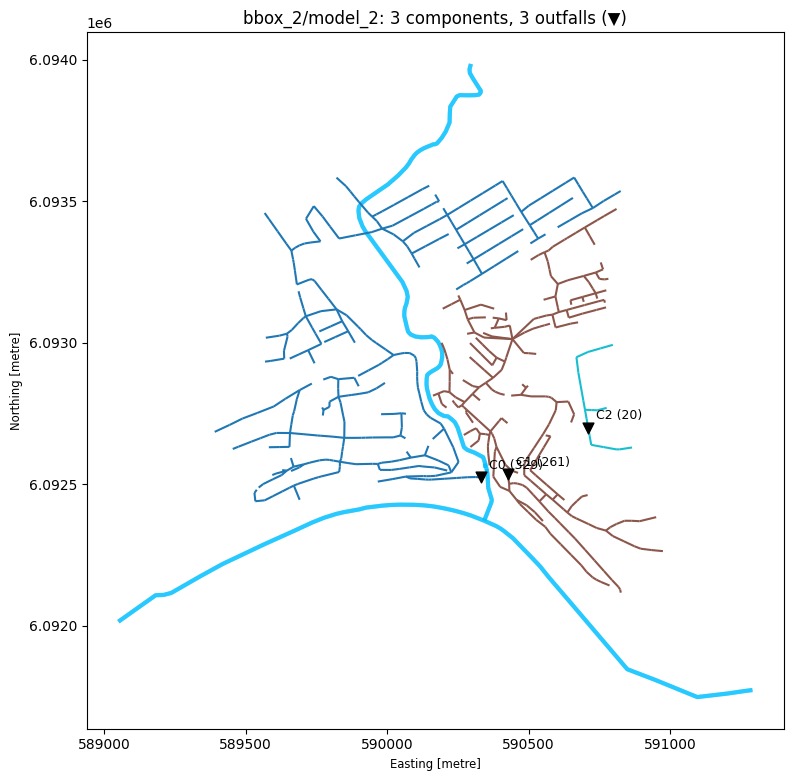

In [4]:
import geopandas as gpd, networkx as nx, matplotlib.pyplot as plt
from pathlib import Path
from swmmanywhere.utilities import load_graph

# Newest model folder (any bbox); or set explicitly, e.g. Path(".../bbox_2/model_1")
m = max(Path("ouseburn_output/ouseburn").glob("bbox_*/model_*"),
        key=lambda p: (p / f"{p.name}.inp").stat().st_mtime if (p / f"{p.name}.inp").exists() else 0)
print("Model:", m)

nodes, edges = gpd.read_parquet(m/"nodes.geoparquet"), gpd.read_parquet(m/"edges.geoparquet")
print(edges["edge_type"].value_counts())
print(edges.groupby("edge_type")["diameter"].describe()[["count", "50%", "max"]])

# River: bbox_N/download/river.json
R = load_graph(m.parent/"download"/"river.json")
river = gpd.GeoSeries([d["geometry"] for *_, d in R.edges(data=True)], crs=edges.crs)

# Components (largest first) and outfalls (nodes with no outgoing pipe)
G = nx.DiGraph(list(zip(edges.u, edges.v)))
comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
comp = {n: i for i, c in enumerate(comps) for n in c}
edges["comp"] = edges.u.map(comp)
sinks = nodes[nodes.id.isin([n for n in G if G.out_degree(n) == 0])].copy()
sinks["comp"] = sinks.id.map(comp)
sinks["comp_size"] = sinks.comp.map(lambda i: len(comps[i]))
sinks["dist_to_river_m"] = sinks.geometry.apply(lambda p: river.distance(p).min()).round(1)
print("\nOutfalls:")
print(sinks[["id", "comp", "comp_size", "surface_elevation", "dist_to_river_m"]]
      .sort_values("comp").to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 11))
river.plot(ax=ax, color="deepskyblue", lw=3, alpha=.6)
edges.plot(ax=ax, column="comp", cmap="tab10" if len(comps) <= 10 else "tab20", lw=1.5)
sinks.plot(ax=ax, color="k", marker="v", markersize=60, zorder=3)
for _, r in sinks.iterrows():
    ax.annotate(f"C{r.comp} ({r.comp_size})", (r.geometry.x, r.geometry.y),
                xytext=(6, 6), textcoords="offset points", fontsize=9)
ax.set_aspect("equal")
ax.set_title(f"{m.parent.name}/{m.name}: {len(comps)} components, {len(sinks)} outfalls (▼)")
plt.show()

## 2–4. Settings and functions: network re-design, sensors, scenarios
This cell only defines things (nothing runs). Edit settings here, e.g. `SENSOR_FRACTION`, `REDESIGN`, `N_RAIN_EVENTS`.


In [5]:
"""
Ouseburn — sensor placement + hydraulic scenario generation (steps 2-4)
=======================================================================
Takes the SWMManywhere model, keeps the main drainage systems, selects ~20 %
of manholes as monitored, then simulates:
  * NORMAL operation : dry-weather base flow + light/moderate rain events
  * DISTURBANCES     : each paired with the normal run under the same rain
        - blockage  : one pipe's diameter reduced to 10-40 % (static)
        - inflow    : extra inflow (burst main / illicit connection /
                      infiltration) injected at one manhole from an onset time
The difference (disturbed - normal) is the "anomaly signal" a graph model
must infer at unmonitored nodes from the monitored ones.

Outputs (DATASET_DIR):
    nodes.csv        node table (coords, invert, depth, component, is_sensor …)
    edges.csv        pipe table (u, v, length, diameter, slope …)
    scenarios.csv    one row per run (type, target, magnitude, rain, QA, impact)
    timeseries.npz   depth / flooding / inflow [S,T,N], flow [S,T,L], times
    checks.txt       network + hydraulic QA summary (step 2)
    sensors_map.png  network with monitored manholes
    example_*.png    footprint of example disturbances

Notebook use: running this cell only DEFINES settings and functions.
The diagnostic cell and the full run cell below use them.
"""

from __future__ import annotations

import contextlib
import os
import re
import shutil
import tempfile
from datetime import datetime, timedelta
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd

# =============================================================================
# SETTINGS
# =============================================================================
MODEL_DIR = None            # None = newest ouseburn_output/ouseburn/bbox_*/model_*
PROJECT_DIR = Path("ouseburn_output/ouseburn")
DATASET_DIR = Path("ouseburn_dataset")

MIN_COMPONENT = 50          # drop drainage systems smaller than this (C2 = 20 nodes)
SENSOR_FRACTION = 0.05      # headline density (is_sensor, plots, stats); must be in SENSOR_DENSITIES
SEED = 42

DURATION_H = 3              # simulated hours per run
REPORT_MIN = 5              # stored time step (minutes)

N_RAIN_EVENTS = 12          # normal-operation events (each = 1 baseline run)
DISTURBANCES_PER_EVENT = 8  # disturbed runs per event  -> 12 * (1+8) = 108 runs
BLOCKAGE_SHARE = 0.5        # rest are inflow disturbances

DWF_LPS_PER_MANHOLE = (0.02, 0.06)   # base (dry-weather) flow range, L/s
RAIN_PEAK_MMH = (0.0, 12.0)          # light-moderate; default storm.dat peaks 34
BLOCKAGE_FACTOR = (0.10, 0.40)       # remaining diameter fraction
# Stronger-disturbance variant (not yet run): DATASET_DIR = Path("ouseburn_dataset_v2"),
# RAIN_PEAK_MMH = (0.0, 25.0), BLOCKAGE_FACTOR = (0.05, 0.25)
INFLOW_LPS = (3.0, 25.0)             # extra inflow at a manhole
AFFECTED_DEPTH_M = 0.05              # |Δdepth| threshold for "affected" nodes
AFFECTED_FLOW_LPS = 0.5              # |Δinflow| must exceed this (L/s) …
AFFECTED_FLOW_REL = 0.10             # … and 10 % of the node's normal peak inflow

# Sensor densities evaluated (nested: each sparser set is a subset of the denser)
SENSOR_DENSITIES = (0.02, 0.05, 0.10, 0.20)
# "practice": like a utility monitoring plan - outlet first, then manholes with
#             the largest upstream drainage area (trunk sewers), kept apart by
#             SENSOR_SPACING_M of pipe so they don't cluster on one trunk.
# "spread"  : farthest-point sampling (even geometric coverage, favours branch tips)
SENSOR_STRATEGY = "practice"
SENSOR_SPACING_M = 150      # min pipe distance between sensors (halved when exhausted)

# Pipe re-design (keeps SWMManywhere's topology; replaces its sizing + grading,
# which on 30 m DEM data gave adverse pipes and 3 m pipes in 1 m-deep manholes)
REDESIGN = True
DESIGN_RAIN_MMH = 50        # rational-method design intensity on impervious area
MIN_GRADIENT = 0.003        # minimum pipe fall (1 in 333) -> no adverse pipes
MIN_COVER_M = 1.0           # ground to pipe crown
STANDARD_DIAMETERS = (0.150, 0.225, 0.300, 0.375, 0.450, 0.525, 0.600, 0.675, 0.750,
                      0.825, 0.900, 1.050, 1.200, 1.350, 1.500, 1.800, 2.100)
MAX_MANHOLE_DEPTH_M = 8.0   # deeper than this -> incoming pipe becomes a pumping station
WETWELL_AREA_M2 = 15.0      # plan area of a pumping-station wet well (damps on/off cycling)
PUMP_FULL_DEPTH_M = 1.0     # wet-well depth at which a pump reaches full capacity
MANHOLE_AREA_M2 = 1.13      # plan area of a 1200 mm manhole (SWMManywhere uses 0.5)

# Surface runoff parameters. SWMManywhere writes zero infiltration/storage, so
# pervious ground runs off like a roof. Typical SWMM-manual values instead:
N_IMPERV, N_PERV = 0.012, 0.15          # Manning's n for overland flow
S_IMPERV_MM, S_PERV_MM = 1.5, 5.0       # depression storage (mm)
PCT_ZERO_STORAGE = 25                   # % of impervious area with no storage
HORTON = (75.0, 5.0, 4.0, 7.0)          # max/min rate (mm/h), decay (1/h), dry time (d)
ROUTING_STEP_S = 1          # SWMManywhere template uses 5 s
QA_MAX_ERROR_PCT = 10       # runs above this |continuity error| get qa_ok = False


# =============================================================================
# 1. READ THE SWMManywhere .inp
# =============================================================================
def find_model_dir() -> Path:
    if MODEL_DIR:
        return Path(MODEL_DIR)
    cands = [p for p in PROJECT_DIR.glob("bbox_*/model_*") if (p / f"{p.name}.inp").exists()]
    if not cands:
        raise FileNotFoundError(f"No model_*.inp under {PROJECT_DIR}")
    return max(cands, key=lambda p: (p / f"{p.name}.inp").stat().st_mtime)


def read_sections(inp: Path) -> dict[str, list[str]]:
    """Return {section: [raw lines]} preserving order (duplicates merged)."""
    sections: dict[str, list[str]] = {}
    cur = None
    for line in inp.read_text().splitlines():
        m = re.match(r"^\s*\[(.+?)\]", line)
        if m:
            cur = m.group(1).upper()
            sections.setdefault(cur, [])
            continue
        if cur is not None:
            sections[cur].append(line)
    return sections


def rows(sections, name) -> list[list[str]]:
    return [l.split() for l in sections.get(name, [])
            if l.strip() and not l.lstrip().startswith(";")]


def parse_network(inp: Path):
    s = read_sections(inp)
    coords = {r[0]: (float(r[1]), float(r[2])) for r in rows(s, "COORDINATES")}
    nodes = []
    for sec, kind in (("STORAGE", "manhole"), ("JUNCTIONS", "manhole"), ("OUTFALLS", "outfall")):
        for r in rows(s, sec):
            nodes.append(dict(node_id=r[0], kind=kind, invert=float(r[1]),
                              max_depth=float(r[2]) if kind == "manhole" else 0.0))
    nodes = pd.DataFrame(nodes)
    nodes["x"] = nodes.node_id.map(lambda n: coords.get(n, (np.nan, np.nan))[0])
    nodes["y"] = nodes.node_id.map(lambda n: coords.get(n, (np.nan, np.nan))[1])
    nodes["surface_elev"] = nodes.invert + nodes.max_depth

    area, imp = {}, {}
    for r in rows(s, "SUBCATCHMENTS"):
        area[r[2]] = area.get(r[2], 0) + float(r[3])           # ha, by outlet node
        imp[r[2]] = imp.get(r[2], 0) + float(r[3]) * float(r[4]) / 100
    nodes["area_ha"] = nodes.node_id.map(area).fillna(0.0)
    nodes["imperv_area_ha"] = nodes.node_id.map(imp).fillna(0.0)

    xs = {r[0]: float(r[2]) for r in rows(s, "XSECTIONS")}
    edges = pd.DataFrame([dict(link_id=r[0], u=r[1], v=r[2], length=float(r[3]),
                               roughness=float(r[4])) for r in rows(s, "CONDUITS")])
    edges["diameter"] = edges.link_id.map(xs)
    inv = nodes.set_index("node_id").invert
    edges["slope"] = (edges.u.map(inv) - edges.v.map(inv)) / edges.length
    return nodes, edges


# =============================================================================
# 2. KEEP MAIN SYSTEMS + NETWORK CHECKS
# =============================================================================
def select_components(nodes, edges):
    G = nx.DiGraph()
    G.add_nodes_from(nodes.node_id)
    G.add_edges_from((u, v, {"length": L}) for u, v, L in zip(edges.u, edges.v, edges.length))
    comps = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
    comp_of = {n: i for i, c in enumerate(comps) for n in c}
    nodes["component"] = nodes.node_id.map(comp_of)
    sizes = nodes.groupby("component").size()
    keep = sizes[sizes >= MIN_COMPONENT].index
    dropped = sizes[sizes < MIN_COMPONENT]
    nodes = nodes[nodes.component.isin(keep)].reset_index(drop=True)
    edges = edges[edges.u.isin(nodes.node_id) & edges.v.isin(nodes.node_id)].reset_index(drop=True)

    # flow-path features
    Gk = G.subgraph(nodes.node_id).copy()
    outlet_mh = {u for u, v in Gk.edges if nodes.set_index("node_id").kind[v] == "outfall"}
    nodes["is_outlet_manhole"] = nodes.node_id.isin(outlet_mh)
    nodes["n_upstream"] = nodes.node_id.map(lambda n: len(nx.ancestors(Gk, n)))
    area = nodes.set_index("node_id").area_ha
    imp = nodes.set_index("node_id").imperv_area_ha
    up_area = {n: area.reindex(list(nx.ancestors(Gk, n)) + [n]).sum() for n in Gk}
    up_imp = {n: imp.reindex(list(nx.ancestors(Gk, n)) + [n]).sum() for n in Gk}
    nodes["upstream_area_ha"] = nodes.node_id.map(up_area)
    nodes["upstream_imperv_ha"] = nodes.node_id.map(up_imp)
    return nodes, edges, Gk, dropped


def network_checks(nodes, edges, dropped) -> list[str]:
    mh = nodes[nodes.kind == "manhole"]
    out = ["NETWORK CHECKS", "=" * 60,
           f"Kept components : {sorted(nodes.component.unique())} "
           f"(sizes {nodes.groupby('component').size().to_dict()})",
           f"Dropped (<{MIN_COMPONENT} nodes): {dropped.to_dict()}",
           f"Manholes {len(mh)}, outfalls {(nodes.kind == 'outfall').sum()}, pipes {len(edges)}"]
    pipes = edges[~edges.v.str.endswith("_outfall")]
    if "link_type" in pipes:
        pipes = pipes[pipes.link_type == "conduit"]
    s = pipes.slope
    out += [f"Pipe slope (m/m): min {s.min():.4f}  median {s.median():.4f}  max {s.max():.4f}",
            f"  adverse (<0): {(s < 0).sum()}   flat (|s|<0.001): {(s.abs() < 1e-3).sum()}   "
            f"steep (>0.1): {(s > 0.1).sum()}",
            f"Diameter (m): median {pipes.diameter.median():.3f}, max {pipes.diameter.max():.3f}; "
            f"share at 0.15 m: {(pipes.diameter <= 0.15).mean():.0%}"]
    # diameter should not shrink downstream
    d_in = pipes.groupby("v").diameter.max()
    d_out = pipes.set_index("u").diameter
    shrink = (d_out.reindex(d_in.index) < d_in).sum()
    out.append(f"Junctions where outgoing pipe is smaller than an incoming pipe: {shrink}")
    out.append(f"Manhole depth (m): min {mh.max_depth.min():.2f} median {mh.max_depth.median():.2f} "
               f"max {mh.max_depth.max():.2f}")
    return out


# =============================================================================
# 3. SENSOR PLACEMENT (~20 %)
# =============================================================================
def practice_order(grp, sub) -> list[str]:
    """Outlet, then largest upstream area, subject to a pipe-distance spacing."""
    area = grp.set_index("node_id").upstream_area_ha
    by_area = sorted(area.index, key=lambda n: (-area[n], n))
    outlet = list(grp[grp.is_outlet_manhole].node_id)[:1]
    chosen = outlet or by_area[:1]
    near = {n: 0.0 for n in chosen}           # distance to nearest chosen sensor
    for c in chosen:
        near.update({k: min(v, near.get(k, np.inf)) for k, v in
                     nx.single_source_dijkstra_path_length(sub, c, weight="length").items()})
    spacing = SENSOR_SPACING_M
    while len(chosen) < len(by_area):
        pick = next((n for n in by_area if n not in chosen and near.get(n, np.inf) >= spacing), None)
        if pick is None:
            spacing /= 2
            if spacing < 1:
                pick = next(n for n in by_area if n not in chosen)
            else:
                continue
        chosen.append(pick)
        for k, v in nx.single_source_dijkstra_path_length(sub, pick, weight="length",
                                                          cutoff=SENSOR_SPACING_M).items():
            near[k] = min(v, near.get(k, np.inf))
    return chosen


def sensor_ranking(nodes, Gk, rng) -> dict[str, int]:
    """Rank every manhole for monitoring (0 = first sensor to install).

    Per system: outlet manhole first, then farthest-point sampling on pipe
    length, so sensors spread over trunk and branches. Systems are
    interleaved in proportion to size. Taking the top-k of the ranking gives
    nested sensor sets: the 5 % set is contained in the 10 % set, etc.
    """
    U = Gk.to_undirected()
    mh = nodes[nodes.kind == "manhole"]
    orders = {}
    for c, grp in mh.groupby("component"):
        cand = set(grp.node_id)
        sub = U.subgraph(cand)
        if SENSOR_STRATEGY == "practice":
            orders[c] = practice_order(grp, sub)
            continue
        chosen = list(grp[grp.is_outlet_manhole].node_id)[:1] or [rng.choice(sorted(cand))]
        dist = dict.fromkeys(cand, np.inf)
        while True:
            d = nx.single_source_dijkstra_path_length(sub, chosen[-1], weight="length")
            for n in cand:
                dist[n] = min(dist[n], d.get(n, np.inf))
            rest = [n for n in cand if n not in chosen]
            if not rest:
                break
            chosen.append(max(rest, key=lambda n: (dist[n], n)))
        orders[c] = chosen
    # interleave systems proportionally to size
    sizes = {c: len(o) for c, o in orders.items()}
    taken = dict.fromkeys(orders, 0)
    rank = {}
    for r in range(len(mh)):
        c = min((c for c in orders if taken[c] < sizes[c]),
                key=lambda c: (taken[c] + 1) / sizes[c])
        rank[orders[c][taken[c]]] = r
        taken[c] += 1
    return rank


def design_network(nodes, edges, Gk) -> list[str]:
    """Standards-based sizing and grading on SWMManywhere's topology.

    1. Design flow per pipe: rational method on upstream impervious area,
       Q = 2.78 * i * A_imp  (L/s, i in mm/h, A in ha), plus base flow.
    2. Design gradient: ground slope, but never less than MIN_GRADIENT.
    3. Diameter: smallest standard size whose Manning full-bore capacity
       carries Q; never smaller than any pipe upstream.
    4. Inverts: from the heads downstream, each pipe at least MIN_COVER_M
       below ground and falling at least the design gradient.
    """
    ni = nodes.set_index("node_id")
    surf, kind = ni.surface_elev.to_dict(), ni.kind.to_dict()
    up_imp = ni.upstream_imperv_ha.to_dict()
    n_up = ni.n_upstream.to_dict()
    key = list(zip(edges.u, edges.v))
    L = dict(zip(key, edges.length)); n_man = dict(zip(key, edges.roughness))

    s_des, D = {}, {}
    for e in key:
        u, v = e
        ground = (surf[u] - surf[v]) / L[e] if kind[v] == "manhole" else MIN_GRADIENT
        s_des[e] = max(ground, MIN_GRADIENT)
        q = (2.78 * DESIGN_RAIN_MMH * up_imp[u] + DWF_LPS_PER_MANHOLE[1] * (n_up[u] + 1)) / 1000
        cap = lambda d: (1 / n_man[e]) * (np.pi * d * d / 4) * (d / 4) ** (2 / 3) * np.sqrt(s_des[e])
        D[e] = next((d for d in STANDARD_DIAMETERS if cap(d) >= q), STANDARD_DIAMETERS[-1])

    order = list(nx.topological_sort(Gk))
    for n in order:                                   # non-decreasing downstream
        din = [D[(u, n)] for u in Gk.predecessors(n)]
        for v in Gk.successors(n):
            D[(n, v)] = max([D[(n, v)]] + din)

    inv, pumps = {}, set()
    for n in order:
        ref = surf[n] if kind[n] == "manhole" else ni.invert[n]   # ground (or outfall level)
        if kind[n] == "manhole":
            d_out = max([D[(n, v)] for v in Gk.successors(n)] or [0.15])
            cands = [surf[n] - MIN_COVER_M - d_out]
        else:
            cands = [ni.invert[n]]
        for u in Gk.predecessors(n):
            arrival = inv[u] - s_des[(u, n)] * L[(u, n)]
            if ref - arrival > MAX_MANHOLE_DEPTH_M:
                pumps.add((u, n))           # lift instead of going deeper
            else:
                cands.append(arrival)
        inv[n] = min(cands)

    q_des = {}
    for e in key:
        u = e[0]
        q_des[e] = 2.78 * DESIGN_RAIN_MMH * up_imp[u] + DWF_LPS_PER_MANHOLE[1] * (n_up[u] + 1)
    edges["link_type"] = ["pump" if e in pumps else "conduit" for e in key]
    edges["pump_capacity_lps"] = [round(1.2 * q_des[e], 2) if e in pumps else np.nan for e in key]
    edges["diameter_original"] = edges.diameter
    edges["slope_original"] = edges.slope
    edges["diameter"] = [D[e] for e in key]
    edges["slope"] = [(inv[u] - inv[v]) / L[(u, v)] for u, v in key]
    nodes["invert_original"] = nodes.invert
    nodes["max_depth_original"] = nodes.max_depth
    nodes["invert"] = nodes.node_id.map(inv)
    nodes["max_depth"] = np.where(nodes.kind == "manhole", nodes.surface_elev - nodes.invert, 0.0)
    return [f"Re-design: rational method {DESIGN_RAIN_MMH} mm/h on impervious area, "
            f"min gradient {MIN_GRADIENT}, min cover {MIN_COVER_M} m, "
            f"max manhole depth {MAX_MANHOLE_DEPTH_M} m -> {len(pumps)} pumping stations"]


# =============================================================================
# 4. SCENARIO WRITING + SIMULATION
# =============================================================================
START = datetime(2000, 1, 1)


def rain_series(rng):
    """Light/moderate event: triangular hyetograph, 5-min steps (mm/h)."""
    peak = rng.uniform(*RAIN_PEAK_MMH)
    if rng.random() < 0.2:
        peak = 0.0                                   # some dry-weather events
    start = int(rng.integers(1, 7)) * 5              # 5-30 min
    dur = int(rng.integers(6, 19)) * 5               # 30-90 min
    t = np.arange(0, dur + 5, 5)
    shape = 1 - np.abs((t - dur * rng.uniform(0.3, 0.6)) / (dur / 1.5))
    vals = np.clip(shape, 0, None) * peak
    return dict(rain_peak_mmh=round(peak, 2), rain_start_min=start, rain_dur_min=dur,
                rain_depth_mm=round(vals.sum() * 5 / 60, 2)), [(start + ti, v) for ti, v in zip(t, vals)]


def prepare_base(sections: dict, edges, nodes) -> dict:
    """Write the (re-)designed network into the parsed .inp, once."""
    s = {k: list(v) for k, v in sections.items()}
    diam = dict(zip(edges.link_id, edges.diameter))
    wetwells = set(edges[edges.link_type == "pump"].u) if "link_type" in edges else set()
    inv = dict(zip(nodes.node_id, nodes.invert))
    dep = dict(zip(nodes.node_id, nodes.max_depth))
    for sec, has_depth in (("STORAGE", True), ("JUNCTIONS", True), ("OUTFALLS", False)):
        for i, l in enumerate(s.get(sec, [])):
            p = l.split()
            if p and not p[0].startswith(";") and p[0] in inv:
                p[1] = f"{inv[p[0]]:.4f}"
                if has_depth:
                    p[2] = f"{dep[p[0]]:.4f}"
                s[sec][i] = " ".join(p)
    data = lambda l: bool(l.split()) and not l.lstrip().startswith(";")
    s["SUBAREAS"] = [l if not data(l) else
                     f"{l.split()[0]} {N_IMPERV} {N_PERV} {S_IMPERV_MM} {S_PERV_MM} {PCT_ZERO_STORAGE} OUTLET"
                     for l in s.get("SUBAREAS", [])]
    s["INFILTRATION"] = [l if not data(l) else f"{l.split()[0]} " + " ".join(map(str, HORTON)) + " 0"
                         for l in s.get("INFILTRATION", [])]
    if "link_type" in edges:
        pmp = edges[edges.link_type == "pump"]
        ids = set(pmp.link_id)
        for sec in ("CONDUITS", "XSECTIONS"):
            s[sec] = [l for l in s.get(sec, []) if not (data(l) and l.split()[0] in ids)]
        s.setdefault("PUMPS", []).extend(f"{r.link_id} {r.u} {r.v} PC_{r.link_id} ON 0 0"
                                         for r in pmp.itertuples())
        for r in pmp.itertuples():          # level-controlled: flow rises with wet-well depth
            s.setdefault("CURVES", []).extend([f"PC_{r.link_id} PUMP4 0 0",
                                               f"PC_{r.link_id} {PUMP_FULL_DEPTH_M} {r.pump_capacity_lps:.3f}",
                                               f"PC_{r.link_id} 50 {r.pump_capacity_lps:.3f}"])
    for i, l in enumerate(s.get("XSECTIONS", [])):
        p = l.split()
        if p and not p[0].startswith(";") and p[0] in diam:
            p[2] = f"{diam[p[0]]:.4f}"
            s["XSECTIONS"][i] = " ".join(p)
    for i, l in enumerate(s.get("STORAGE", [])):
        p = l.split()
        if p and not p[0].startswith(";") and len(p) >= 8 and p[4].upper() == "FUNCTIONAL":
            p[7] = f"{WETWELL_AREA_M2 if p[0] in wetwells else MANHOLE_AREA_M2}"  # A = a*D^b + c
            s["STORAGE"][i] = " ".join(p)
    return s


def write_scenario_inp(base: dict, path: Path, rain, dwf: dict, blockage=None, inflow=None):
    s = {k: list(v) for k, v in base.items()}
    end = START + timedelta(hours=DURATION_H)

    # options
    def set_opt(key, val):
        for i, l in enumerate(s["OPTIONS"]):
            if l.split() and l.split()[0].upper() == key:
                s["OPTIONS"][i] = f"{key:<21}{val}"
                return
        s["OPTIONS"].append(f"{key:<21}{val}")
    set_opt("END_DATE", end.strftime("%m/%d/%Y"))
    set_opt("END_TIME", end.strftime("%H:%M:%S"))
    set_opt("REPORT_STEP", f"00:{REPORT_MIN:02d}:00")
    set_opt("ROUTING_STEP", f"{ROUTING_STEP_S}")
    set_opt("WET_STEP", "00:01:00")       # runoff step during rain (template: 5 min)

    # rainfall file (quoted path: Drive folders contain spaces)
    rain_file = path.with_suffix(".rain.dat")
    lines = [f"1 {(START + timedelta(minutes=int(m))).strftime('%Y %m %d %H %M')} {v:.3f}"
             for m, v in rain]
    lines.append(f"1 {(START + timedelta(minutes=int(rain[-1][0]) + 5)).strftime('%Y %m %d %H %M')} 0.000")
    if rain[0][0] > 0:
        lines.insert(0, f"1 {START.strftime('%Y %m %d %H %M')} 0.000")
    rain_file.write_text("\n".join(lines) + "\n")
    s["RAINGAGES"] = [l for l in s["RAINGAGES"] if l.lstrip().startswith(";")]
    s["RAINGAGES"].append(f'1 INTENSITY 00:05 1 FILE "{rain_file.resolve()}" 1 MM')

    # dry-weather (base) flow
    s["DWF"] = [";;Node Constituent Baseline"] + [f"{n} FLOW {q:.4f}" for n, q in dwf.items()]

    # blockage: shrink diameter of one conduit
    if blockage:
        link, factor = blockage
        for i, l in enumerate(s["XSECTIONS"]):
            p = l.split()
            if p and p[0] == link:
                p[2] = f"{max(float(p[2]) * factor, 0.03):.4f}"
                s["XSECTIONS"][i] = " ".join(p)

    # extra inflow from onset time
    if inflow:
        node, q, onset = inflow
        t0 = START + timedelta(minutes=onset)
        fmt = lambda t: t.strftime("%m/%d/%Y %H:%M")
        s["TIMESERIES"] = [";;Name Date Time Value",
                           f"ts_dist {fmt(START)} 0", f"ts_dist {fmt(t0)} 0",
                           f"ts_dist {fmt(t0 + timedelta(minutes=2))} {q:.3f}",
                           f"ts_dist {fmt(end)} {q:.3f}"]
        s["INFLOWS"] = [";;Node Constituent TimeSeries Type Mfactor Sfactor",
                        f'{node} FLOW ts_dist FLOW 1.0 1.0']
    path.write_text("\n".join(f"[{k}]\n" + "\n".join(v) + "\n" for k, v in s.items()))


@contextlib.contextmanager
def _quiet():
    """Silence SWMM's C-level console output (it bypasses sys.stdout)."""
    import sys
    sys.stdout.flush()
    saved = os.dup(1)
    with open(os.devnull, "w") as null:
        os.dup2(null.fileno(), 1)
        try:
            yield
        finally:
            os.dup2(saved, 1)
            os.close(saved)


def run_swmm(inp: Path, node_ids, link_ids):
    from pyswmm import Output, Simulation
    from swmm.toolkit.shared_enum import LinkAttribute, NodeAttribute

    with _quiet(), Simulation(str(inp)) as sim:
        sim.step_advance(REPORT_MIN * 60)
        for _ in sim:
            pass
    # continuity errors from the report file (pyswmm's properties return 0 here)
    rpt = inp.with_suffix(".rpt").read_text()
    def cont(block):          # only inside that block: dry runs have no runoff block
        m = re.search(re.escape(block) + r"(.*?)\n[ \t]*\n[ \t]*\n", rpt, re.S)
        e = re.search(r"Continuity Error \(%\) \.+\s+(-?[\d.]+)", m.group(1)) if m else None
        return float(e.group(1)) if e else 0.0
    qa = dict(runoff_error_pct=cont("Runoff Quantity Continuity"),
              routing_error_pct=cont("Flow Routing Continuity"))
    with Output(str(inp.with_suffix(".out"))) as out:
        times = out.times
        get = lambda attr, ids, fn: np.array(
            [[fn(attr, t).get(i, np.nan) for i in ids] for t in range(len(times))], np.float32)
        res = dict(depth=get(NodeAttribute.INVERT_DEPTH, node_ids, out.node_attribute),
                   flood=get(NodeAttribute.FLOODING_LOSSES, node_ids, out.node_attribute),
                   inflow=get(NodeAttribute.TOTAL_INFLOW, node_ids, out.node_attribute),
                   flow=get(LinkAttribute.FLOW_RATE, link_ids, out.link_attribute))
    return times, res, qa


# =============================================================================
# 5. MAIN
# =============================================================================
def main():
    rng = np.random.default_rng(SEED)
    model_dir = find_model_dir()
    inp = model_dir / f"{model_dir.name}.inp"
    print(f"Model: {inp}")
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    nodes_all, edges_all = parse_network(inp)
    nodes, edges, Gk, dropped = select_components(nodes_all, edges_all)
    checks = ["AS GENERATED BY SWMManywhere"] + network_checks(nodes, edges, dropped)

    if REDESIGN:
        checks += [""] + design_network(nodes, edges, Gk)
        checks += ["AFTER RE-DESIGN"] + network_checks(nodes, edges, dropped)[5:]

    rank = sensor_ranking(nodes, Gk, rng)
    nodes["sensor_rank"] = nodes.node_id.map(rank).astype("Int64")
    n_mh = (nodes.kind == "manhole").sum()
    for dens in SENSOR_DENSITIES:
        nodes[f"sensor_{int(dens * 100):02d}"] = (nodes.sensor_rank < round(dens * n_mh)).fillna(False).astype(bool)
    nodes["is_sensor"] = (nodes.sensor_rank < round(SENSOR_FRACTION * n_mh)).fillna(False).astype(bool)
    sensors = set(nodes[nodes.is_sensor].node_id)
    mh = nodes[nodes.kind == "manhole"]
    checks.append(f"Sensor strategy: {SENSOR_STRATEGY}; headline {SENSOR_FRACTION:.0%} = "
                  f"{len(sensors)} sensors; median upstream area at sensors "
                  f"{mh[mh.is_sensor].upstream_area_ha.median():.2f} ha vs all manholes "
                  f"{mh.upstream_area_ha.median():.2f} ha")
    print(f"Sensors ({SENSOR_STRATEGY}): {len(sensors)} of {len(mh)} manholes "
          f"({len(sensors) / len(mh):.0%}); per system "
          f"{mh[mh.is_sensor].groupby('component').size().to_dict()}")

    # dry-weather flow on ALL manholes in the model (incl. dropped systems)
    all_mh = nodes_all[nodes_all.kind == "manhole"].node_id
    dwf_base = dict(zip(all_mh, rng.uniform(*DWF_LPS_PER_MANHOLE, len(all_mh))))

    # candidate disturbance locations (kept systems only)
    pipes = edges[~edges.v.str.endswith("_outfall")]
    if "link_type" in pipes:
        pipes = pipes[pipes.link_type == "conduit"]
    blk_cands = pipes[pipes.u.map(lambda n: Gk.in_degree(n) > 0)].link_id.tolist() or pipes.link_id.tolist()
    inf_cands = mh.node_id.tolist()

    node_ids, link_ids = nodes.node_id.tolist(), edges.link_id.tolist()
    base_sections = prepare_base(read_sections(inp), edges, nodes)
    work = Path(tempfile.mkdtemp(prefix="ouseburn_runs_"))   # local disk, not Drive
    meta, D, F, Q, L = [], [], [], [], []
    times = None
    sid = 0
    n_total = N_RAIN_EVENTS * (1 + DISTURBANCES_PER_EVENT)

    try:
        for ev in range(N_RAIN_EVENTS):
            rain_meta, rain = rain_series(rng)
            dwf = {n: q * rng.uniform(0.8, 1.2) for n, q in dwf_base.items()}
            plan = [("normal", None, None)]
            for _ in range(DISTURBANCES_PER_EVENT):
                if rng.random() < BLOCKAGE_SHARE:
                    plan.append(("blockage", rng.choice(blk_cands), round(rng.uniform(*BLOCKAGE_FACTOR), 3)))
                else:
                    plan.append(("inflow", rng.choice(inf_cands), round(rng.uniform(*INFLOW_LPS), 2)))
            base_idx = sid
            for kind, target, mag in plan:
                onset = int(rng.integers(3, 18)) * 5 if kind == "inflow" else 0
                p = work / f"s{sid:04d}.inp"
                write_scenario_inp(base_sections, p, rain, dwf,
                                   blockage=(target, mag) if kind == "blockage" else None,
                                   inflow=(target, mag, onset) if kind == "inflow" else None)
                t, r, qa = run_swmm(p, node_ids, link_ids)
                times = times or t
                D.append(r["depth"]); F.append(r["flood"]); Q.append(r["inflow"]); L.append(r["flow"])
                row = dict(scenario_id=sid, event_id=ev, baseline_id=base_idx, kind=kind,
                           target=target, magnitude=mag, onset_min=onset, **rain_meta, **qa)
                if kind != "normal":
                    dd = np.abs(r["depth"] - D[base_idx]).max(axis=0)
                    row["n_affected_nodes"] = int((dd > AFFECTED_DEPTH_M).sum())
                    row["max_delta_depth_m"] = round(float(dd.max()), 3)
                    row["sensors_affected"] = int((dd[nodes.is_sensor.values] > AFFECTED_DEPTH_M).sum())
                    dq = np.abs(r["inflow"] - Q[base_idx]).max(axis=0)
                    qref = np.abs(Q[base_idx]).max(axis=0)
                    hit = dq > np.maximum(AFFECTED_FLOW_LPS, AFFECTED_FLOW_REL * qref)
                    row["n_flow_affected_nodes"] = int(hit.sum())
                    row["sensors_flow_affected"] = int(hit[nodes.is_sensor.values].sum())
                    seen = hit | (dd > AFFECTED_DEPTH_M)
                    for dens in SENSOR_DENSITIES:
                        col = f"sensor_{int(dens * 100):02d}"
                        row[f"seen_{col}"] = bool(seen[nodes[col].values].any())
                row["flooding_nodes"] = int((r["flood"].max(axis=0) > 0).sum())
                row["qa_ok"] = bool(abs(qa["routing_error_pct"]) <= QA_MAX_ERROR_PCT)
                meta.append(row)
                for f in work.glob(f"s{sid:04d}.*"):
                    f.unlink()
                sid += 1
                print(f"\r  run {sid}/{n_total}  ({kind:<8})", end="", flush=True)
        print()
    finally:
        shutil.rmtree(work, ignore_errors=True)

    sc = pd.DataFrame(meta)
    nodes.to_csv(DATASET_DIR / "nodes.csv", index=False)
    edges.to_csv(DATASET_DIR / "edges.csv", index=False)
    sc.to_csv(DATASET_DIR / "scenarios.csv", index=False)
    np.savez_compressed(DATASET_DIR / "timeseries.npz",
                        depth=np.stack(D), flood=np.stack(F), inflow=np.stack(Q), flow=np.stack(L),
                        times=np.array([str(t) for t in times]),
                        node_ids=np.array(node_ids), link_ids=np.array(link_ids),
                        scenario_ids=sc.scenario_id.values)

    # hydraulic QA (step 2)
    nrm, dis = sc[sc.kind == "normal"], sc[sc.kind != "normal"]
    checks += ["", "HYDRAULIC CHECKS", "=" * 60,
               f"Runs: {len(sc)} ({len(nrm)} normal, {(sc.kind == 'blockage').sum()} blockage, "
               f"{(sc.kind == 'inflow').sum()} inflow); {len(times)} steps of {REPORT_MIN} min",
               f"Flow routing continuity error %: median {sc.routing_error_pct.abs().median():.2f}, "
               f"95th pct {sc.routing_error_pct.abs().quantile(.95):.2f}, max "
               f"{sc.routing_error_pct.abs().max():.2f} (aim < 5); runs > {QA_MAX_ERROR_PCT}%: "
               f"{(~sc.qa_ok).sum()} (qa_ok = False)",
               f"Normal runs - nodes flooding: median {nrm.flooding_nodes.median():.0f}, "
               f"max {nrm.flooding_nodes.max()}",
               f"Disturbances - affected nodes (|Δdepth|>{AFFECTED_DEPTH_M} m): median "
               f"{dis.n_affected_nodes.median():.0f}, zero-impact runs {(dis.n_affected_nodes == 0).sum()}",
               f"Disturbances seen by >=1 sensor - depth: {(dis.sensors_affected > 0).mean():.0%}, "
               f"flow: {(dis.sensors_flow_affected > 0).mean():.0%}, "
               f"either: {((dis.sensors_affected > 0) | (dis.sensors_flow_affected > 0)).mean():.0%}",
               "Detection (depth or flow at >=1 sensor) by sensor density, impactful runs only:"]
    imp = dis[dis.n_affected_nodes + dis.n_flow_affected_nodes > 0]
    for dens in SENSOR_DENSITIES:
        col = f"seen_sensor_{int(dens * 100):02d}"
        checks.append(f"   {dens:>4.0%} ({nodes[col[5:]].sum():>3} sensors): {imp[col].mean():.0%}")
    (DATASET_DIR / "checks.txt").write_text("\n".join(checks) + "\n")
    print("\n".join(checks))

    make_plots(nodes, edges, sc, np.stack(D))
    print(f"\n✓ Dataset written to {DATASET_DIR.resolve()}")


def make_plots(nodes, edges, sc, depth):
    try:
        import matplotlib.pyplot as plt
        from matplotlib.collections import LineCollection
    except ImportError:
        return
    xy = nodes.set_index("node_id")[["x", "y"]]
    segs = [[xy.loc[u].values, xy.loc[v].values] for u, v in zip(edges.u, edges.v)]

    def base(ax, title):
        ax.add_collection(LineCollection(segs, colors="#9bb7d0", linewidths=1))
        ax.set_aspect("equal"); ax.set_title(title, fontsize=10)
        ax.autoscale(); ax.set_xticks([]); ax.set_yticks([])

    fig, ax = plt.subplots(figsize=(8, 9))
    mh = nodes[nodes.kind == "manhole"]
    base(ax, f"Nested sensor sets ({len(mh)} manholes); headline "
             f"{SENSOR_FRACTION:.0%} = {nodes.is_sensor.sum()} sensors")
    ax.scatter(mh.x, mh.y, s=6, c="#bbbbbb", zorder=2, label="unmonitored")
    # draw densest first so sparser (subset) sets sit on top
    dens_sorted = sorted(SENSOR_DENSITIES, reverse=True)
    colours = ["#fdd0a2", "#fd8d3c", "#d94801", "#7f2704"]
    sizes = [25, 40, 60, 90]
    prev = None
    for i, dens in enumerate(dens_sorted):
        col = f"sensor_{int(dens * 100):02d}"
        sel = mh[mh[col]]
        ax.scatter(sel.x, sel.y, s=sizes[i % 4], c=colours[i % 4], edgecolor="k", lw=0.6,
                   zorder=3 + i, label=f"{dens:.0%} ({len(sel)})")
    of = nodes[nodes.kind == "outfall"]
    ax.scatter(of.x, of.y, s=80, marker="v", c="k", zorder=3, label="outfall")
    ax.legend(loc="upper left")
    fig.tight_layout(); fig.savefig(DATASET_DIR / "sensors_map.png", dpi=150); plt.close(fig)

    dis = sc[sc.kind != "normal"].sort_values("n_affected_nodes", ascending=False)
    for kind in ("blockage", "inflow"):
        sub = dis[dis.kind == kind]
        if sub.empty:
            continue
        r = sub.iloc[len(sub) // 3]                       # a typical, not extreme, case
        dd = (depth[r.scenario_id] - depth[r.baseline_id]).max(axis=0)
        fig, ax = plt.subplots(figsize=(8, 9))
        base(ax, f"{kind}: {r.target} (mag {r.magnitude}) — max Δdepth per node")
        lim = max(abs(dd).max(), 1e-3)
        sca = ax.scatter(nodes.x, nodes.y, c=dd, cmap="RdBu_r", vmin=-lim, vmax=lim, s=14, zorder=2)
        sn = nodes[nodes.is_sensor]
        ax.scatter(sn.x, sn.y, s=60, facecolors="none", edgecolors="k", zorder=3)
        if kind == "blockage":
            e = edges.set_index("link_id").loc[r.target]
            ax.plot(*zip(xy.loc[e.u], xy.loc[e.v]), c="k", lw=4, zorder=4)
        else:
            ax.scatter(*xy.loc[r.target], marker="*", s=300, c="gold", edgecolor="k", zorder=4)
        fig.colorbar(sca, ax=ax, shrink=0.6, label="Δ depth (m)")
        fig.tight_layout(); fig.savefig(DATASET_DIR / f"example_{kind}.png", dpi=150); plt.close(fig)


## Diagnose hydraulics (≈1 min)
Run this before the full run.


In [6]:
# Continuity / flooding diagnostic — uses the settings and functions defined above.
# Two short simulations (~1 min). Check: routing error small, 0 adverse pipes,
# few or no flooded nodes in the light-rain run.
# Wrapped in a function so its variables can't overwrite the definitions above.

def diagnose():
    work = Path("/tmp/ouseburn_diag"); work.mkdir(exist_ok=True)
    inp = (m := find_model_dir()) / f"{m.name}.inp"
    nodes_all, edges_all = parse_network(inp)
    nodes, edges, Gk, _ = select_components(nodes_all, edges_all)
    if REDESIGN: design_network(nodes, edges, Gk)
    base = prepare_base(read_sections(inp), edges, nodes)
    dwf = {n: 0.04 for n in nodes_all[nodes_all.kind == "manhole"].node_id}
    ni = nodes.set_index("node_id"); ei = edges.set_index("link_id")
    cond = edges[edges.get("link_type", "conduit") == "conduit"] if "link_type" in edges else edges
    out_slope = cond.groupby("u").slope.min()
    wetwell = set(edges[edges.link_type == "pump"].u) if "link_type" in edges else set()

    def section(rpt, title):
        """Body of a report section (between its title banner and the next banner)."""
        m = re.search(rf"\*+\s*\n\s*{re.escape(title)}\s*\n\s*\*+\s*\n(.*?)(?=\n\s*\*{{5,}}\s*\n|\Z)", rpt, re.S)
        return m.group(1) if m else ""

    def table_rows(body):
        parts = re.split(r"\n\s*-{10,}\s*\n", body)
        return [l.split() for l in parts[-1].splitlines() if l.strip()] if len(parts) >= 3 else []

    def run(name, rain):
        p = work / f"{name}.inp"
        write_scenario_inp(base, p, rain, dwf)
        from pyswmm import Simulation
        with _quiet(), Simulation(str(p)) as sim:
            for _ in sim: pass
        return p.with_suffix(".rpt").read_text()

    for name, rain in [("dry", [(10, 0.0)]),
                       ("rain", [(10, 4.0), (15, 8.0), (20, 12.0), (25, 8.0), (30, 4.0)])]:
        rpt = run(name, rain)
        def cont(block):
            m = re.search(re.escape(block) + r"(.*?)\n[ \t]*\n[ \t]*\n", rpt, re.S)
            e = re.search(r"Continuity Error \(%\) \.+\s+(-?[\d.]+)", m.group(1)) if m else None
            return e.group(1) if e else "n/a (no such block)"
        print(f"\n=== {name.upper()} run: continuity error % - runoff {cont('Runoff Quantity Continuity')}, "
              f"routing {cont('Flow Routing Continuity')}")

        rows = [l.split() for l in section(rpt, "Highest Continuity Errors").splitlines() if l.strip()]
        top = [(r[1], r[2].strip("()%")) for r in rows if len(r) >= 3]
        print(f"Highest node continuity errors ({len(top)} listed):")
        for n, pct in top:
            inn, out = edges[edges.v == n], edges[edges.u == n]
            print(f"  {n:>12} {pct:>7}%  upA={ni.upstream_area_ha.get(n, np.nan):6.2f} ha  "
                  f"depth={ni.max_depth.get(n, np.nan):4.2f}  dIn={inn.diameter.max() if len(inn) else 0:.3f} "
                  f"dOut={out.diameter.max() if len(out) else 0:.3f}  slopeOut={out_slope.get(n, np.nan):+.3f}")
        if top:
            adv = np.mean([out_slope.get(n, 0) < 0 for n, _ in top])
            print(f"  -> {np.mean([n in wetwell for n, _ in top]):.0%} of these are pumping-station wet wells")
        print(f"  -> {adv:.0%} of these have an ADVERSE (uphill) outgoing pipe "
                  f"(network-wide: {(out_slope < 0).mean():.0%} of manholes)")

        for t in ("Time-Step Critical Elements", "Highest Flow Instability Indexes",
                  "Most Frequent Nonconverging Nodes"):
            body = section(rpt, t).strip()
            print(f"{t}: {body.splitlines()[0] if body else '-'}" if len(body.splitlines()) <= 1 else
                  f"{t}:\n" + "\n".join("    " + l.strip() for l in body.splitlines()[:6]))

        fl = section(rpt, "Node Flooding Summary")
        rows = table_rows(fl)
        print(f"Flooded nodes: {len(rows)}" + ("" if rows else "  (no flooding)"))
        for r in sorted(rows, key=lambda r: -float(r[2]))[:8]:
            n = r[0]; inn, out = edges[edges.v == n], edges[edges.u == n]
            if n not in ni.index:
                print(f"  {n:>12} hrs={r[1]:>6} maxQ={r[2]:>7} LPS  (in a dropped small system - ignore)"); continue
            print(f"  {n:>12} hrs={r[1]:>6} maxQ={r[2]:>7} LPS  depth={ni.max_depth.get(n, np.nan):4.2f}  "
                  f"dIn={inn.diameter.max() if len(inn) else 0:.3f} dOut={out.diameter.max() if len(out) else 0:.3f} "
                  f"slopeOut={out_slope.get(n, np.nan):+.3f}")
        if rows:
            adv = np.mean([out_slope.get(r[0], 0) < 0 for r in rows])
            print(f"  -> {adv:.0%} of flooded nodes have an adverse outgoing pipe")

    d = edges[~edges.v.str.endswith("_outfall") & (edges.get("link_type", "conduit") == "conduit")]
    print("\nDiameters after re-design (m: count):", d.diameter.round(3).value_counts().sort_index().to_dict())
    print(f"Pipes >= 1.5 m: {(d.diameter >= 1.5).sum()} after re-design vs {(d.diameter_original >= 1.5).sum()} as generated")
    mhd = nodes[nodes.kind == "manhole"].max_depth
    print(f"Pumping stations: {(edges.get('link_type', '') == 'pump').sum()}; manhole depth "
          f"> 4 m: {(mhd > 4).sum()}, > 6 m: {(mhd > 6).sum()} (limit {MAX_MANHOLE_DEPTH_M} m)")
    print(f"Adverse pipes: {(d.slope < 0).sum()} after vs {(d.slope_original < 0).sum()} as generated; "
          f"manhole depth median {nodes[nodes.kind == 'manhole'].max_depth.median():.2f} m, "
          f"max {nodes[nodes.kind == 'manhole'].max_depth.max():.2f} m")


diagnose()



=== DRY run: continuity error % - runoff 0.000, routing -2.961
Highest node continuity errors (5 listed):
           422    3.30%  upA=  0.00 ha  depth=1.62  dIn=0.150 dOut=0.150  slopeOut=+0.003
           501    3.26%  upA=  0.00 ha  depth=1.39  dIn=0.150 dOut=0.150  slopeOut=+0.003
           705    2.77%  upA=  0.35 ha  depth=2.45  dIn=0.225 dOut=0.225  slopeOut=+0.003
           890    2.57%  upA=  0.12 ha  depth=3.31  dIn=0.150 dOut=0.150  slopeOut=+0.003
           666    2.55%  upA=  0.18 ha  depth=1.32  dIn=0.150 dOut=0.225  slopeOut=+0.003
  -> 0% of these are pumping-station wet wells
  -> 0% of these have an ADVERSE (uphill) outgoing pipe (network-wide: 0% of manholes)
Time-Step Critical Elements: None
Highest Flow Instability Indexes: All links are stable.
Most Frequent Nonconverging Nodes: Convergence obtained at all time steps.
Flooded nodes: 0  (no flooding)

=== RAIN run: continuity error % - runoff -0.060, routing -0.831
Highest node continuity errors (5 listed):
   

## Full scenario run → `ouseburn_dataset/`


Model: ouseburn_output/ouseburn/bbox_2/model_2/model_2.inp
Sensors (practice): 30 of 590 manholes (5%); per system {0: 17, 1: 13}
  run 108/108  (blockage)
AS GENERATED BY SWMManywhere
NETWORK CHECKS
Kept components : [np.int64(0), np.int64(1)] (sizes {0: 330, 1: 262})
Dropped (<50 nodes): {2: 21}
Manholes 590, outfalls 2, pipes 590
Pipe slope (m/m): min -0.5303  median 0.0141  max 1.7316
  adverse (<0): 75   flat (|s|<0.001): 21   steep (>0.1): 82
Diameter (m): median 0.150, max 3.000; share at 0.15 m: 51%
Junctions where outgoing pipe is smaller than an incoming pipe: 130
Manhole depth (m): min 1.00 median 2.11 max 6.00

Re-design: rational method 50 mm/h on impervious area, min gradient 0.003, min cover 1.0 m, max manhole depth 8.0 m -> 25 pumping stations
AFTER RE-DESIGN
Pipe slope (m/m): min 0.0030  median 0.0107  max 1.9655
  adverse (<0): 0   flat (|s|<0.001): 0   steep (>0.1): 102
Diameter (m): median 0.300, max 1.350; share at 0.15 m: 34%
Junctions where outgoing pipe is small

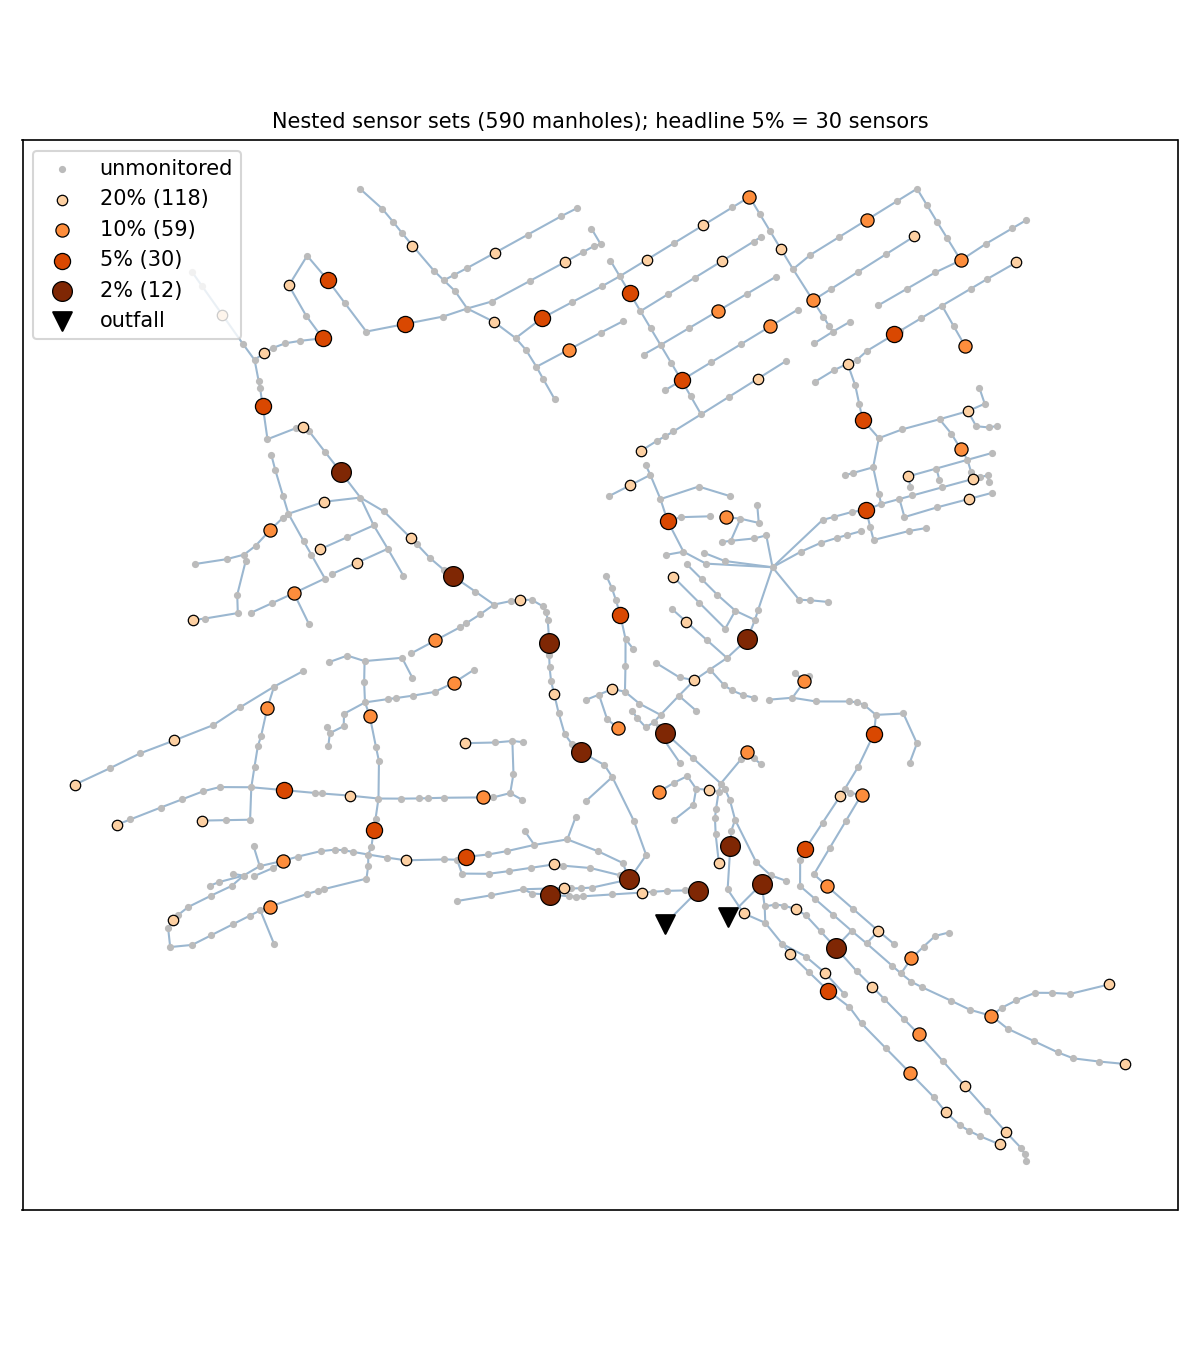

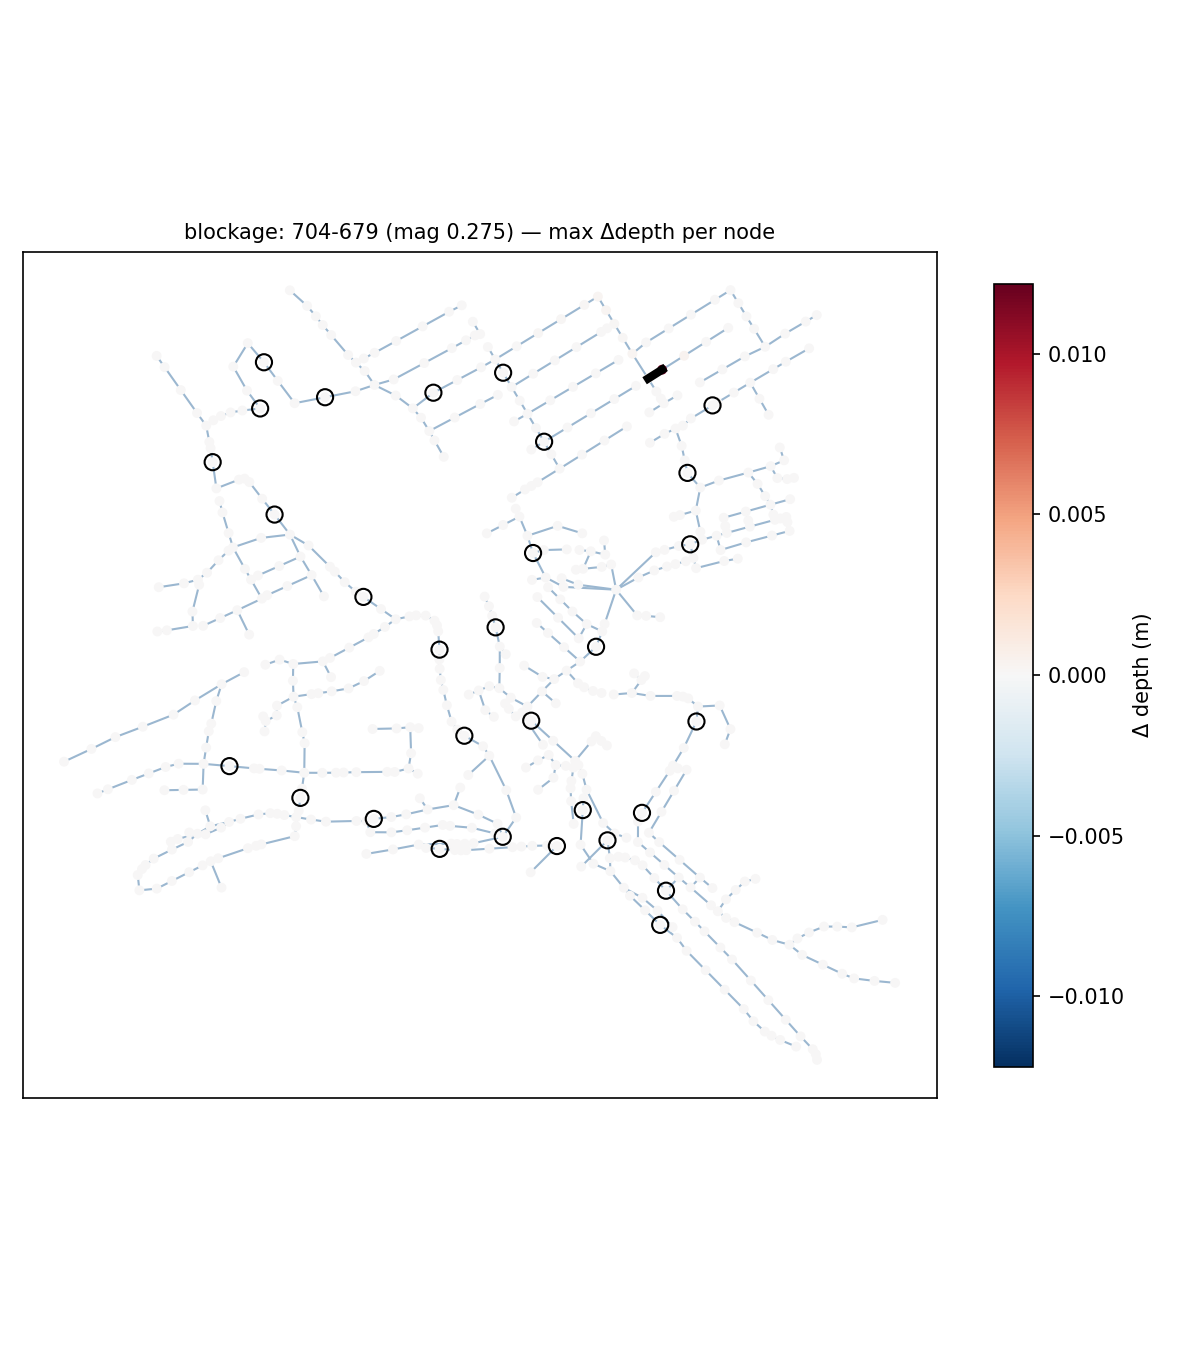

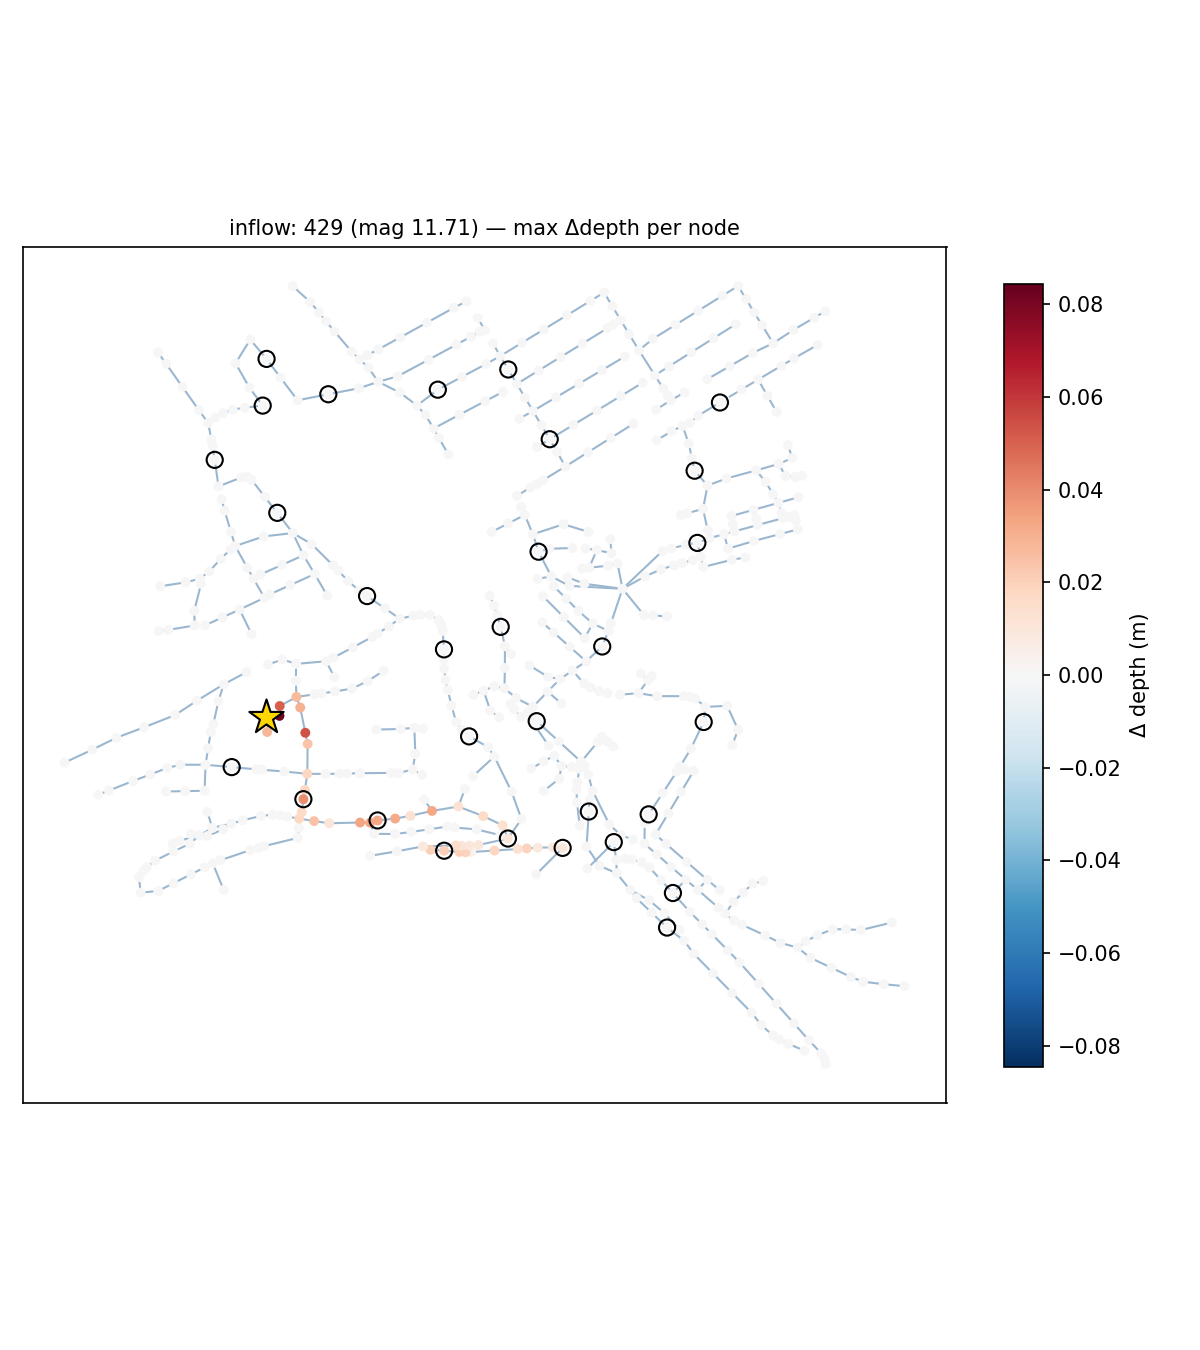

In [7]:
# Full scenario run (108 SWMM runs; ~15-40 min with the 1 s routing step)
main()

from IPython.display import Image, display
for f in ("sensors_map.png", "example_blockage.png", "example_inflow.png"):
    if (DATASET_DIR / f).exists():
        display(Image(filename=str(DATASET_DIR / f), width=650))
